# Analysis Summary: Histogram Normalization for Resolution Invariance

## 1. Objective
The goal of this experiment was to compare two images with identical visual content but significantly different spatial resolutions. The study demonstrates why raw histograms fail as image descriptors when image sizes differ and how **Histogram Normalization** solves this problem.

In [1]:
import matplotlib.pyplot as plt
import cv2

In [2]:
import thisModule as tm

## 2. Data Preparation
A source image (`cat.jpeg`) was resized to create two distinct samples:
* **Low Resolution Image:** $128 \times 128$ pixels (Total: 16,384 pixels).
* **High Resolution Image:** $512 \times 512$ pixels (Total: 262,144 pixels).

In [ ]:

img = cv2.imread("preprocessDB/cat.jpeg")

low_res  = cv2.resize(img, (128, 128))
high_res = cv2.resize(img, (512, 512))

cv2.imwrite("img_low.jpg", low_res)
cv2.imwrite("img_high.jpg", high_res)

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(low_res, cv2.COLOR_BGR2RGB))
plt.title("Low resolution")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(high_res, cv2.COLOR_BGR2RGB))
plt.title("High resolution")
plt.show()


In [9]:
high_res_img=tm.ImageAsArray("img_high.jpg","preprocessDB")
low_res_img=tm.ImageAsArray("img_low.jpg","preprocessDB")

Text(0.5, 1.0, 'Low resolution image')

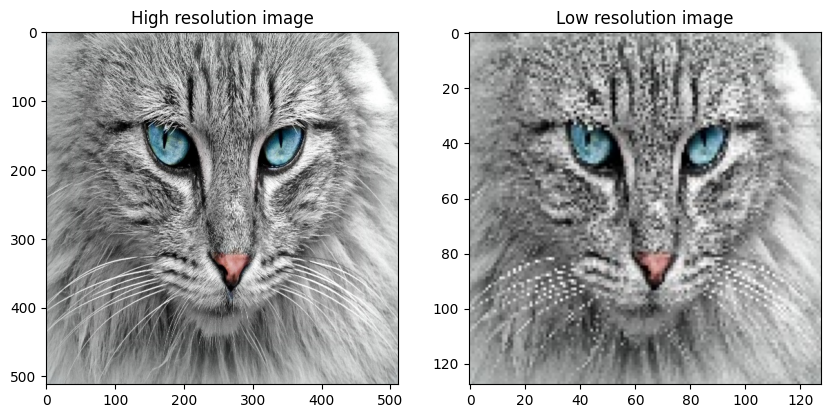

In [10]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(high_res_img)
plt.title("High resolution image")
plt.subplot(1,2,2)
plt.imshow(low_res_img)
plt.title("Low resolution image")

## 3. The Problem: Comparison of Raw Histograms
We calculated the pixel intensity histograms for both images. Since a standard histogram counts the *absolute number* of pixels for each intensity value, the High Resolution image produces counts approximately **16 times higher** than the Low Resolution image.

In [11]:
hist_high=tm.ds.histo(high_res_img)
hist_low=tm.ds.histo(low_res_img)

In [15]:
print("distance between histograms (high res vs low res):", tm.EuclideanDistance(hist_high, hist_low))

distance between histograms (high res vs low res): 55565.29899136691


### Quantitative Failure
Using **Euclidean Distance** to compare the raw histograms resulted in a misleadingly massive distance value, suggesting the images were completely different:
* **Raw Histogram Distance:** `55,565.3`

<BarContainer object of 256 artists>

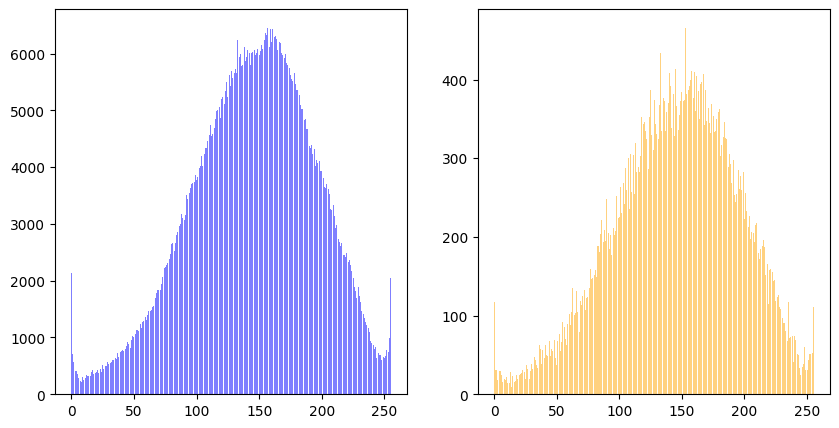

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(range(256), hist_high, alpha=0.5, label='High Res Histogram', color='blue')
plt.subplot(1,2,2)
plt.bar(range(256), hist_low, alpha=0.5, label='Low Res Histogram', color='orange')

## 4. The Solution: Histogram Normalization
To perform a fair comparison, we must convert the absolute pixel counts into **probabilities** (frequencies). This is achieved by dividing each bin in the histogram by the total number of pixels in that specific image.

**Formula:**
$$H_{norm}(i) = \frac{H_{raw}(i)}{\text{Total Pixels}}$$

In [13]:
normalized_hist_high = hist_high / high_res.size
normalized_hist_low = hist_low / low_res.size

In [16]:
print("distance between histograms (high res vs low res):", tm.EuclideanDistance(normalized_hist_high, normalized_hist_low))

distance between histograms (high res vs low res): 0.0064173798475204375


<BarContainer object of 256 artists>

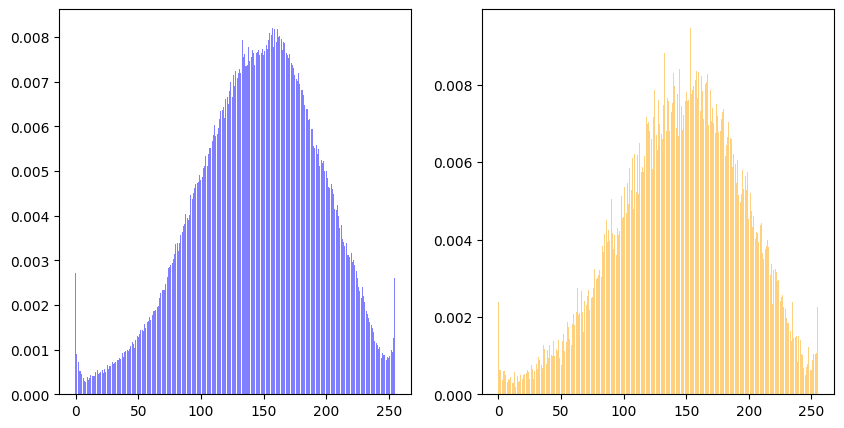

In [14]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(range(256), normalized_hist_high, alpha=0.5, label='High Res Histogram', color='blue')
plt.subplot(1,2,2)
plt.bar(range(256), normalized_hist_low, alpha=0.5, label='Low Res Histogram', color='orange')

## 5. Results & Conclusion
After **normalization**, the y-axis of the histogram represents the percentage of pixels at a specific intensity, making the descriptor independent of the image size.